In [1]:
import glob
import gc
import time
import random
import math
import pickle

import numpy as np
from sklearn import linear_model
import scipy.sparse as sp
from scipy.spatial.distance import cdist

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

import palantir

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/l

In [2]:
## Import Organoid Data ##

scz_adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

# remove stressed glia and doublets
scz_adata = scz_adata[(scz_adata.obs['subclass_annotations'] != 'Stressed Glia') & (~scz_adata.obs['pred_dbl'])].copy()

# define pseudobulk column 
scz_adata.obs['Donor_Sample'] = scz_adata.obs['Donor'].astype('str') + '_' + scz_adata.obs['Sample Name'].astype('str')
scz_adata.obs['Donor_Sample_Celltype'] = scz_adata.obs['Donor_Sample'] + '_' + scz_adata.obs['CellType'].astype('str')
gc.collect()

4262

In [3]:
## HVG PB ##

hvg_df = pd.DataFrame(data=scz_adata[:,scz_adata.var.highly_variable_features].layers['raw_counts'].toarray(),
             index=scz_adata.obs_names,
             columns=scz_adata[:,scz_adata.var.highly_variable_features].var_names)

hvg_df['subtype_cluster_annotations'] = scz_adata.obs['subtype_cluster_annotations']

hvg_pbd = hvg_df.groupby('subtype_cluster_annotations').mean()

## SCVI PB ##

scvi_df = pd.DataFrame(data=scz_adata.obsm['X_scVI'],
                     index=scz_adata.obs_names,
                     columns=[f"LATENT_DIM_{str(i)}" for i in range(scz_adata.obsm['X_scVI'].shape[1])])

scvi_df['subtype_cluster_annotations'] = scz_adata.obs['subtype_cluster_annotations']

scvi_pbd = scvi_df.groupby('subtype_cluster_annotations').mean()

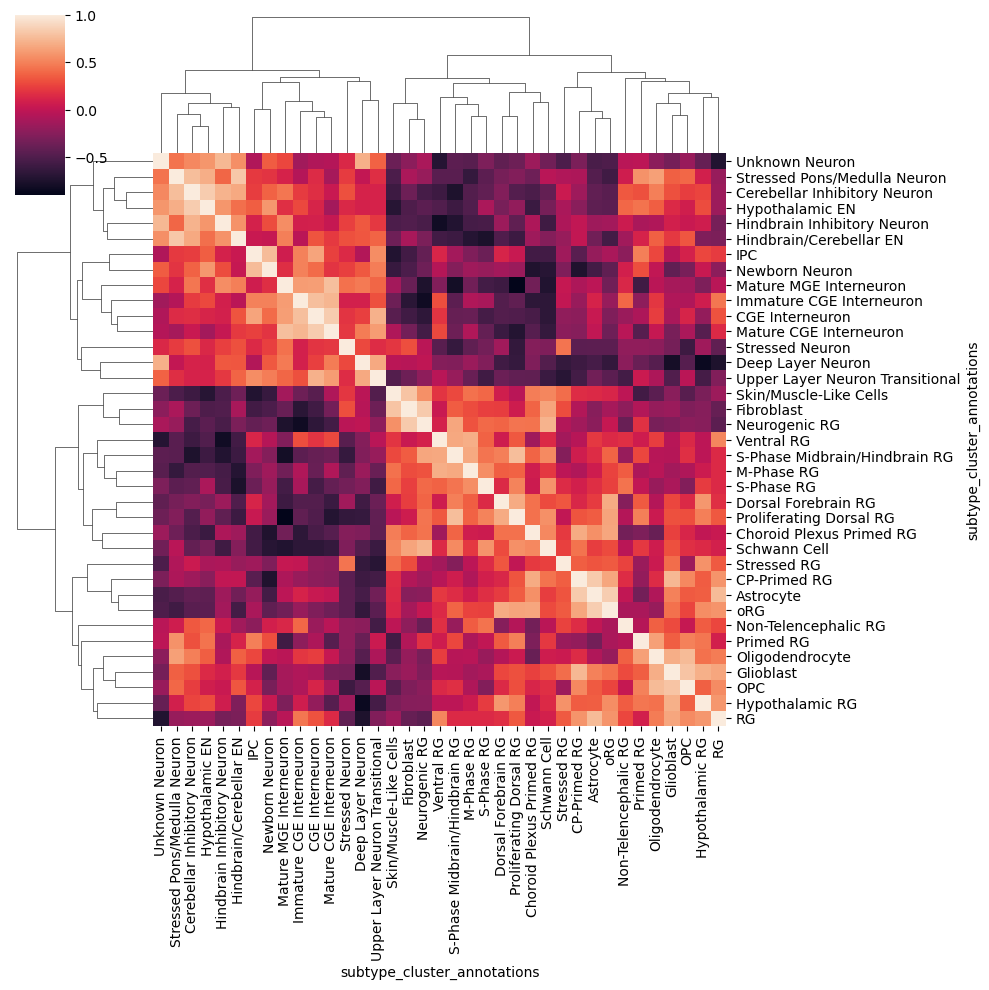

In [4]:
sns.clustermap(scvi_pbd.T.corr())

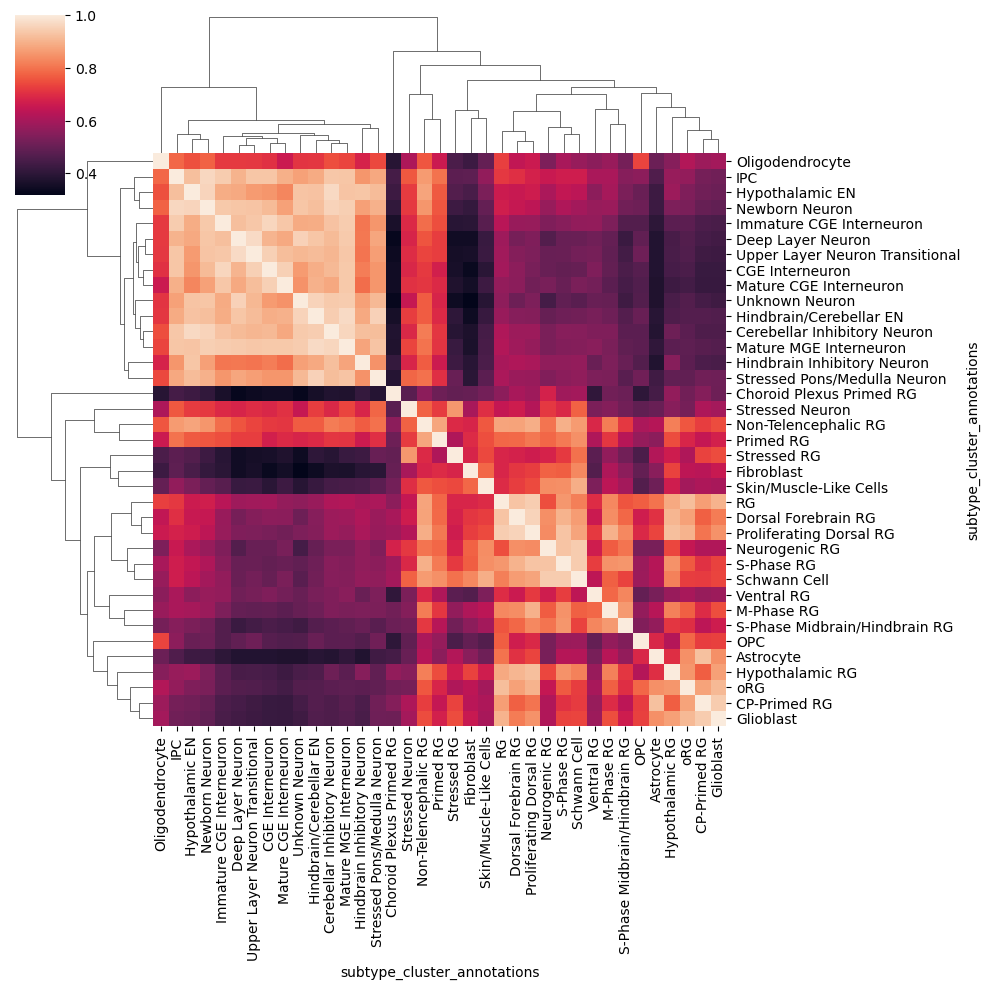

In [5]:
sns.clustermap(hvg_pbd.T.corr())

In [6]:
scvi_pbd.T.corr()['IPC'].sort_values(ascending=False)[0:10]

subtype_cluster_annotations
IPC                                1.000000
Newborn Neuron                     0.767806
CGE Interneuron                    0.653862
Upper Layer Neuron Transitional    0.553192
Immature CGE Interneuron           0.502338
Primed RG                          0.493364
Hypothalamic EN                    0.359571
Hypothalamic RG                    0.273415
Oligodendrocyte                    0.268904
Mature CGE Interneuron             0.244801
Name: IPC, dtype: float64

In [7]:
hvg_pbd.T.corr()['IPC'].sort_values(ascending=False)[0:20]

subtype_cluster_annotations
IPC                                1.000000
Newborn Neuron                     0.963118
Immature CGE Interneuron           0.942361
Cerebellar Inhibitory Neuron       0.933862
CGE Interneuron                    0.932782
Upper Layer Neuron Transitional    0.932041
Mature MGE Interneuron             0.931051
Hypothalamic EN                    0.920530
Deep Layer Neuron                  0.901336
Mature CGE Interneuron             0.894046
Hindbrain/Cerebellar EN            0.886517
Stressed Pons/Medulla Neuron       0.881898
Unknown Neuron                     0.870870
Non-Telencephalic RG               0.860349
Hindbrain Inhibitory Neuron        0.851350
Primed RG                          0.798685
Oligodendrocyte                    0.783564
Stressed Neuron                    0.761476
RG                                 0.716418
Dorsal Forebrain RG                0.703056
Name: IPC, dtype: float64

In [8]:
scvi_pbd.T.corr()['Newborn Neuron'].sort_values(ascending=False)[0:10]

subtype_cluster_annotations
Newborn Neuron                     1.000000
IPC                                0.767806
Hypothalamic EN                    0.594666
Immature CGE Interneuron           0.502286
Upper Layer Neuron Transitional    0.485296
CGE Interneuron                    0.413541
Cerebellar Inhibitory Neuron       0.376558
Unknown Neuron                     0.353293
Deep Layer Neuron                  0.335416
Primed RG                          0.297147
Name: Newborn Neuron, dtype: float64

In [9]:
scvi_pbd.T.corr()['Deep Layer Neuron'].sort_values(ascending=False)[0:10]

subtype_cluster_annotations
Deep Layer Neuron                  1.000000
Unknown Neuron                     0.704307
Upper Layer Neuron Transitional    0.674464
Mature CGE Interneuron             0.475807
Mature MGE Interneuron             0.471045
Hindbrain Inhibitory Neuron        0.339536
Newborn Neuron                     0.335416
Hindbrain/Cerebellar EN            0.326415
Stressed Neuron                    0.275133
CGE Interneuron                    0.237139
Name: Deep Layer Neuron, dtype: float64

In [10]:
## Dorsal Forebrain Trajectory 3#

rg_ipc_neuron_bool = scz_adata.obs['subtype_cluster_annotations'].str.contains('Dorsal|IPC|Radial|Deep|Upper|Newborn')

# primed_rg_bool = (scz_adata.obs['subtype_cluster_annotations'] == 'Primed RG')

gaba_ipc_bool = scz_adata.obs['CellType'].str.contains('GABA|IPC') 

# gaba_rg_bool = (scz_adata.obs['subtype_cluster_annotations'] == 'RG') | (scz_adata.obs['subtype_cluster_annotations'] == 'Ventral RG')

# dorsal_prolif_rg_bool = ((scz_adata.obs['subclass_annotations'].str.contains('Prolif')) &
#                          (~scz_adata.obs['subtype_cluster_annotations'].str.contains('Ventral|Non|Hind')))

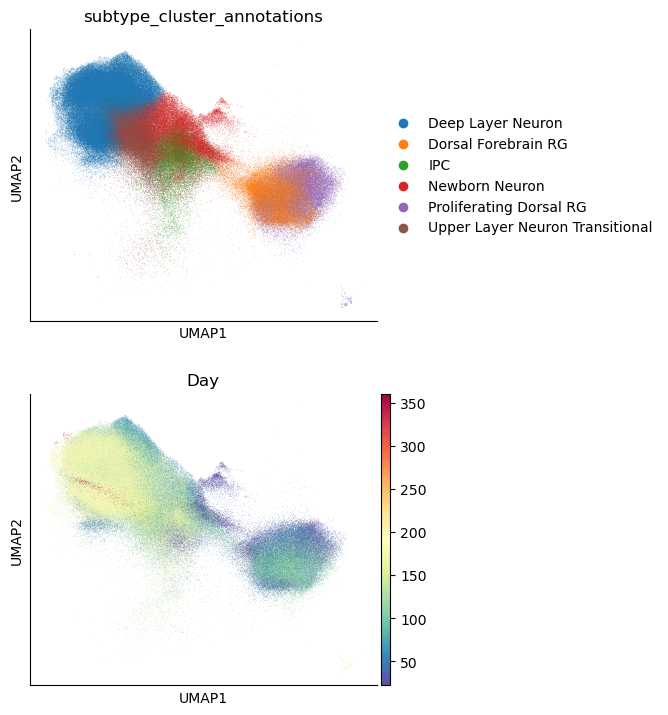

In [11]:
sc.pl.umap(scz_adata[rg_ipc_neuron_bool], color=['subtype_cluster_annotations', 'Day'], ncols=1)

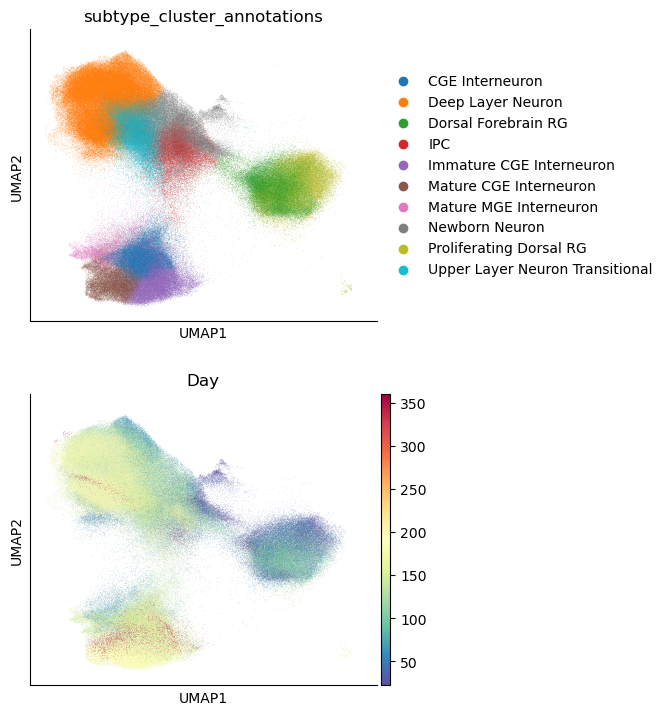

In [12]:
sc.pl.umap(scz_adata[rg_ipc_neuron_bool | gaba_ipc_bool], color=['subtype_cluster_annotations', 'Day'], ncols=1)

In [13]:
ei_adata = scz_adata[rg_ipc_neuron_bool | gaba_ipc_bool].copy()

In [14]:
sc.pp.neighbors(ei_adata, n_neighbors=15, use_rep='X_scVI')
sc.tl.leiden(ei_adata, resolution=2)

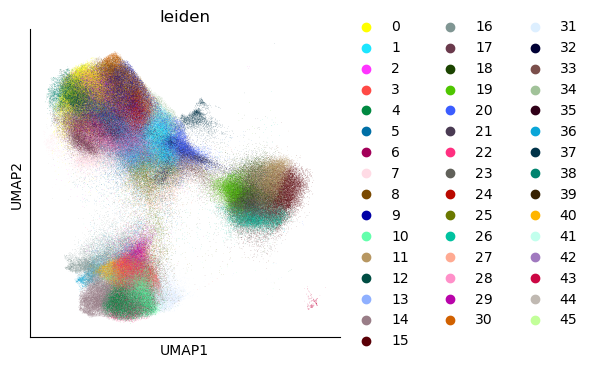

In [15]:
sc.pl.umap(ei_adata, color='leiden')

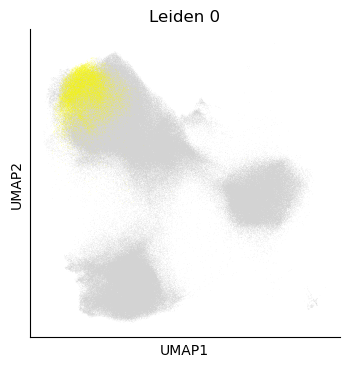

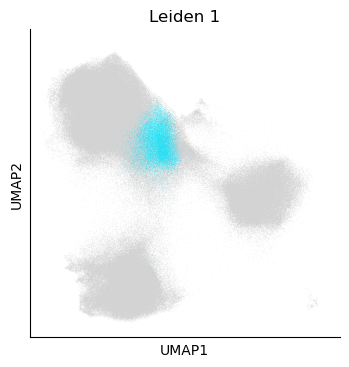

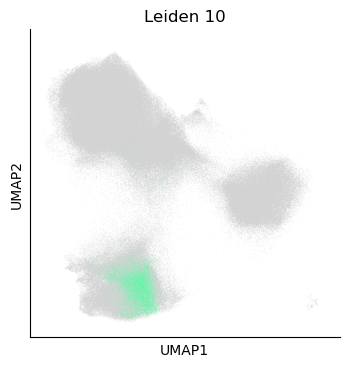

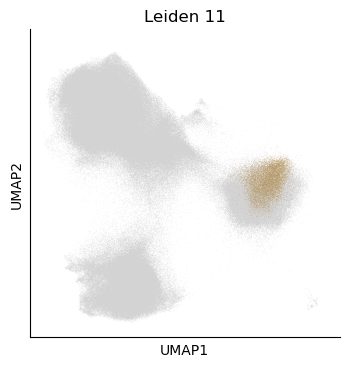

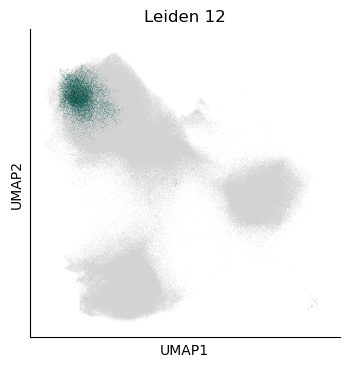

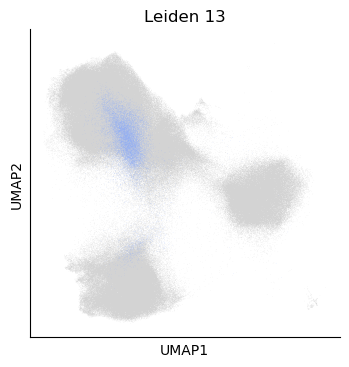

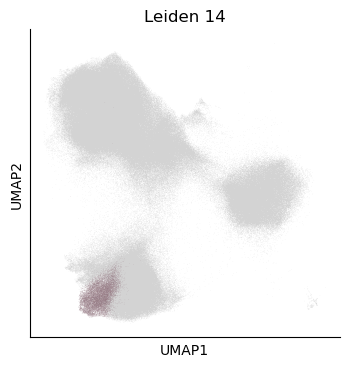

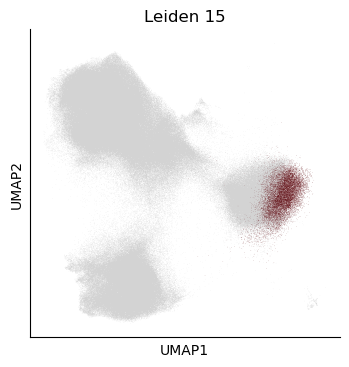

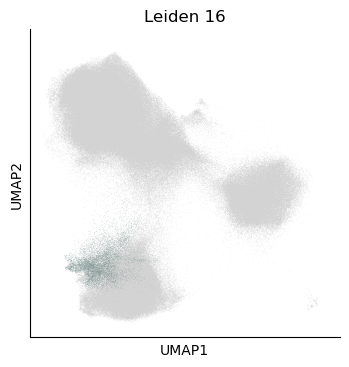

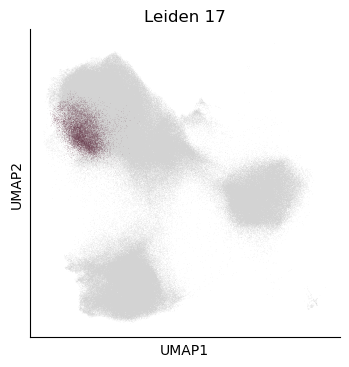

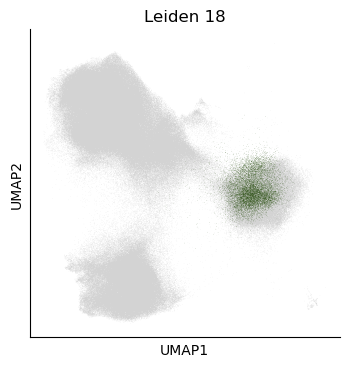

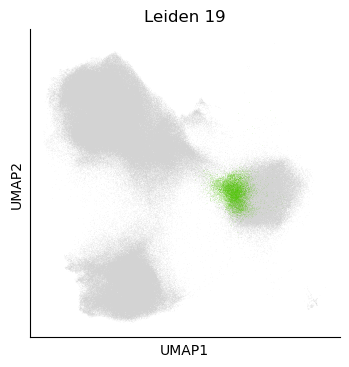

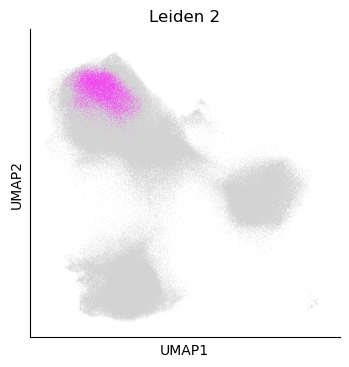

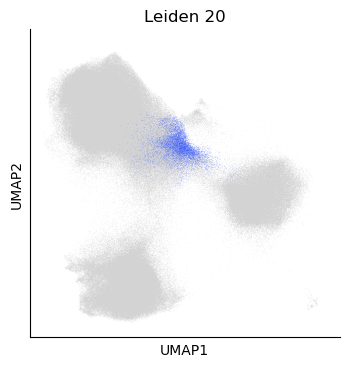

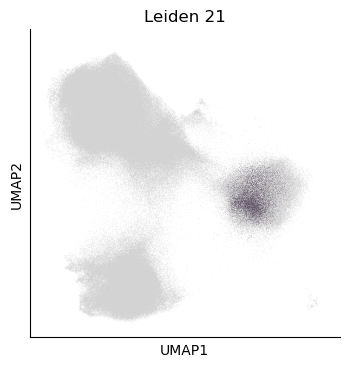

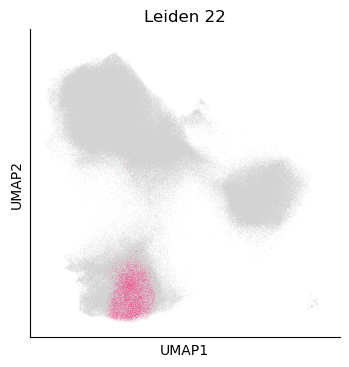

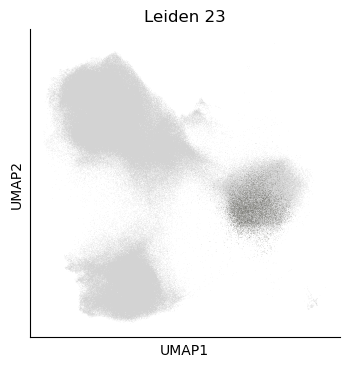

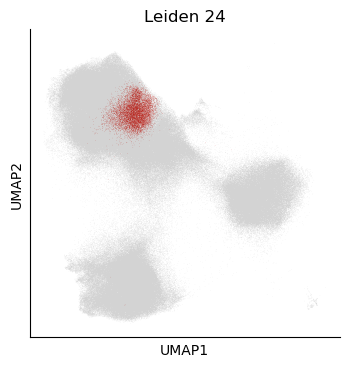

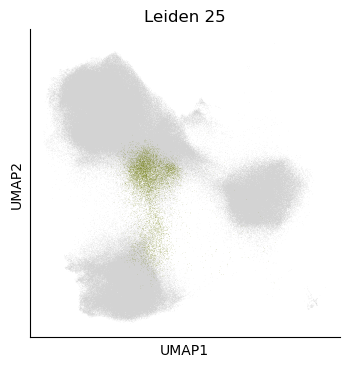

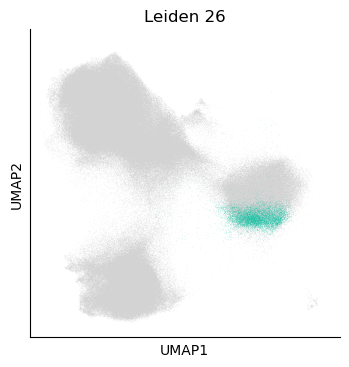

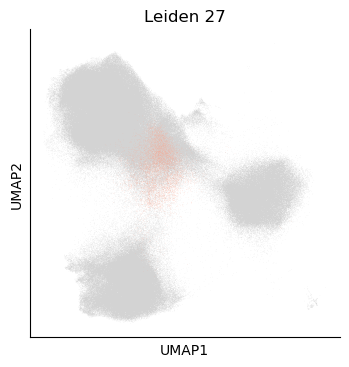

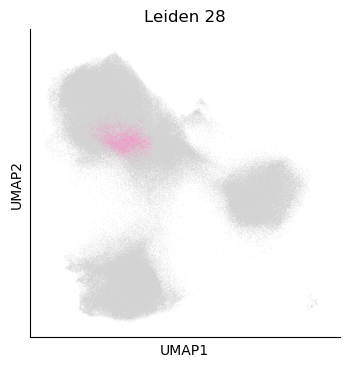

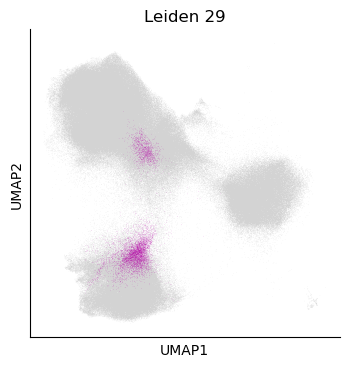

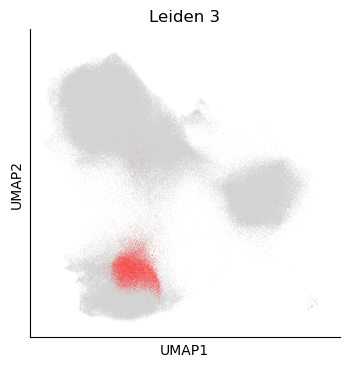

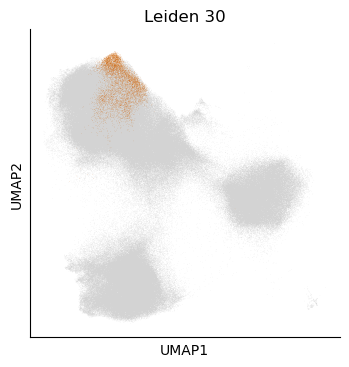

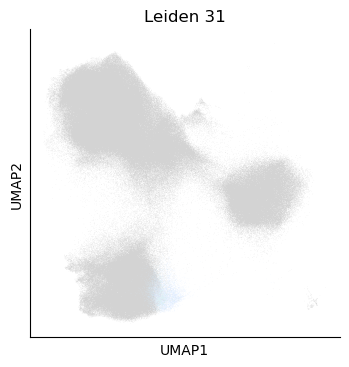

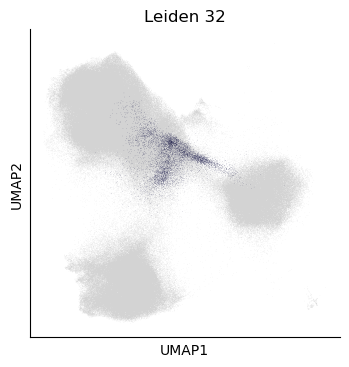

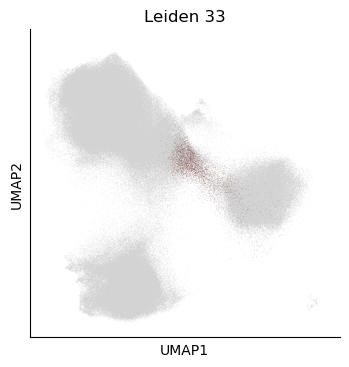

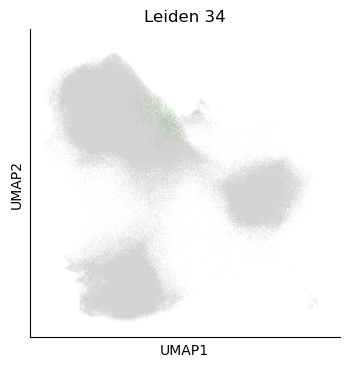

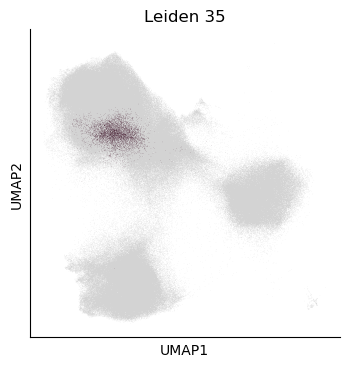

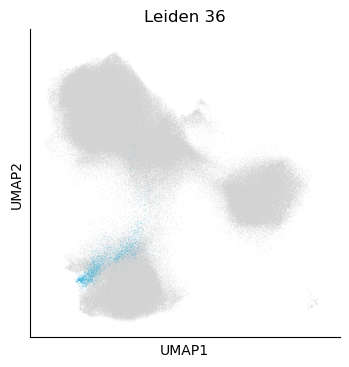

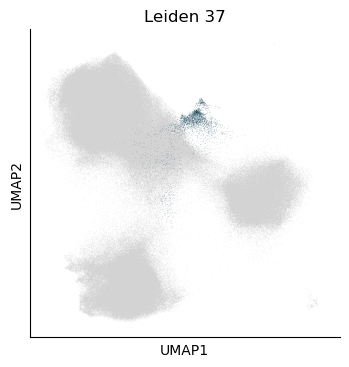

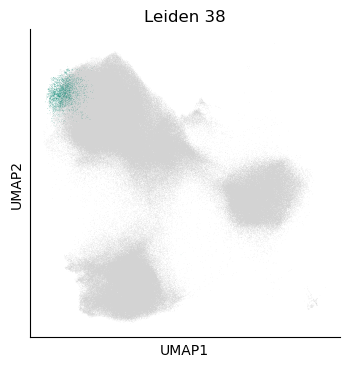

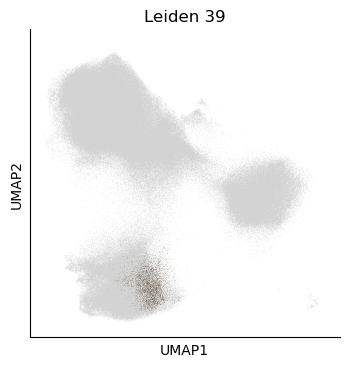

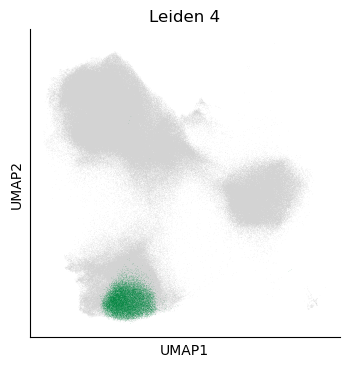

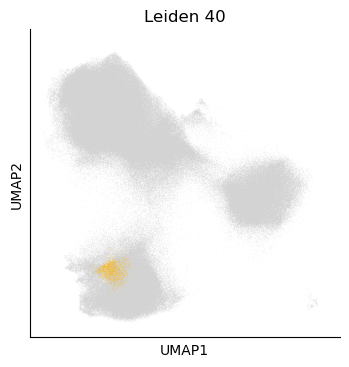

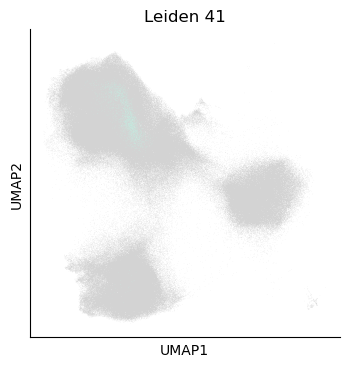

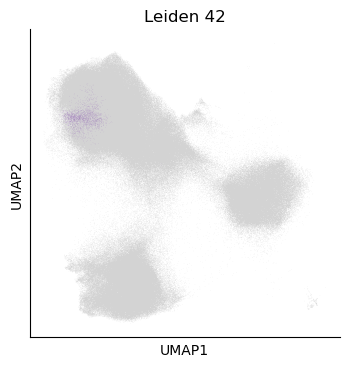

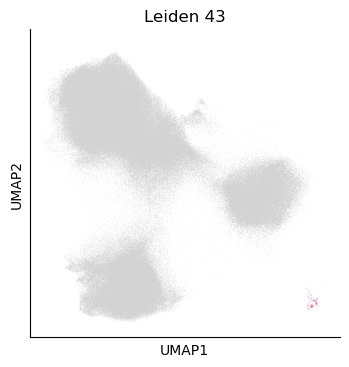

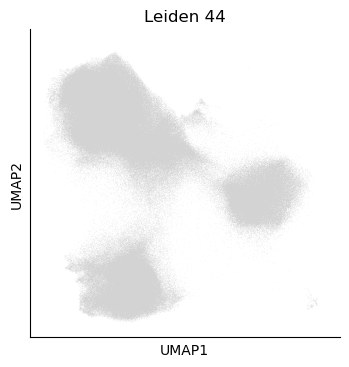

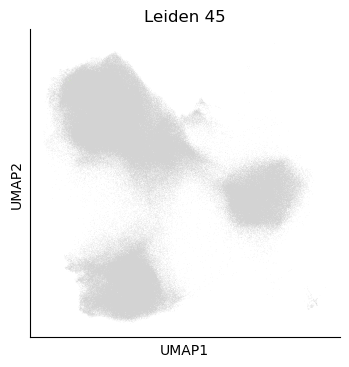

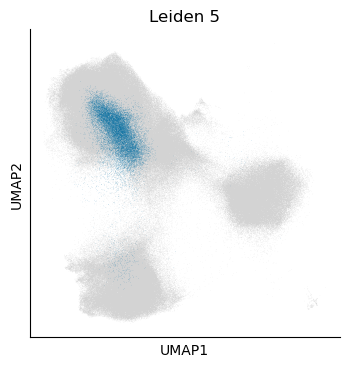

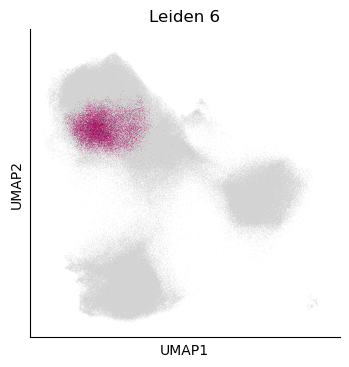

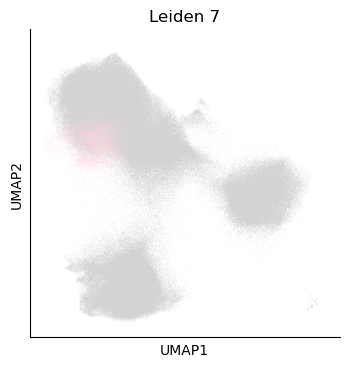

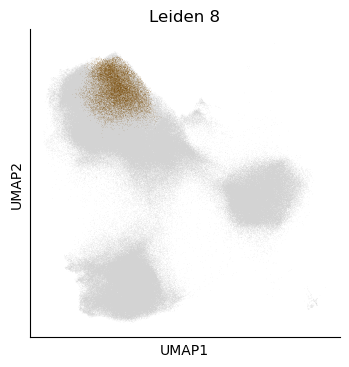

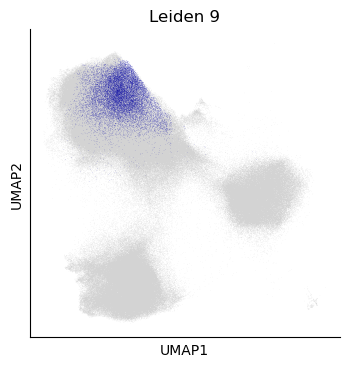

In [16]:
clusters = sorted(ei_adata.obs['leiden'].unique())

for cl in clusters:
    sc.pl.umap(
        ei_adata,
        color='leiden',
        groups=[cl],
        title=f'Leiden {cl}',
        legend_loc=None
    )

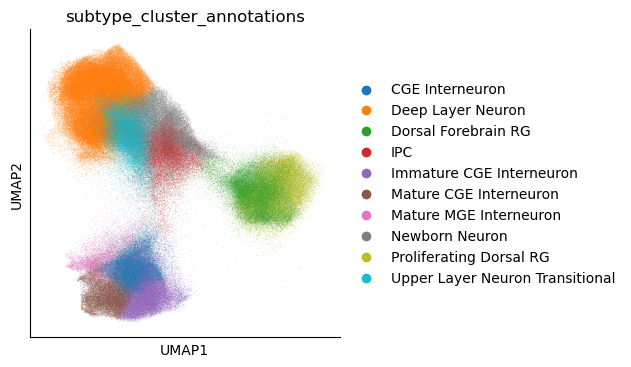

In [18]:
sc.pl.umap(ei_adata[~ei_adata.obs['leiden'].isin(['37', '43'])], color='subtype_cluster_annotations')

In [19]:
## Clean Up Outliers ##

ei_adata = ei_adata[~ei_adata.obs['leiden'].isin(['37', '43'])].copy()
gc.collect()

14831

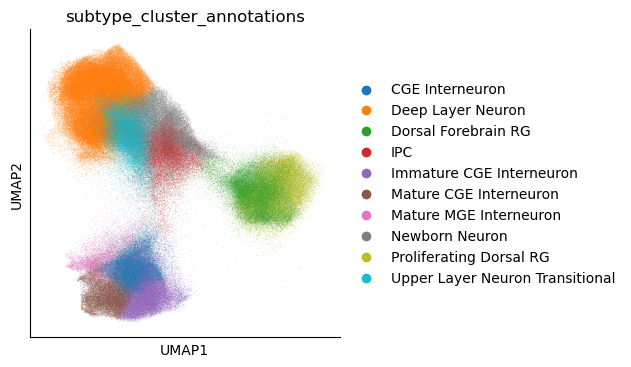

In [20]:
sc.pl.umap(ei_adata, color='subtype_cluster_annotations')

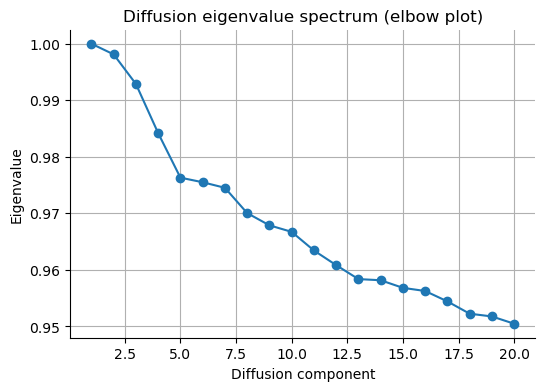

In [21]:
# Identify Number of Diffusion Components #

dm_res = palantir.utils.run_diffusion_maps(ei_adata, n_components=20, pca_key='X_scVI')

eigvals = dm_res['EigenValues']

# Plot elbow curve
plt.figure(figsize=(6,4))
plt.plot(range(1, len(eigvals)+1), eigvals, 'o-', markersize=6)
plt.xlabel("Diffusion component")
plt.ylabel("Eigenvalue")
plt.title("Diffusion eigenvalue spectrum (elbow plot)")
plt.grid(True)
plt.show()

In [22]:
## Recalculate Neighbors For Usable Connectivity Graph ##

sc.pp.neighbors(ei_adata, n_neighbors=15, n_pcs=20, use_rep='X_scVI')

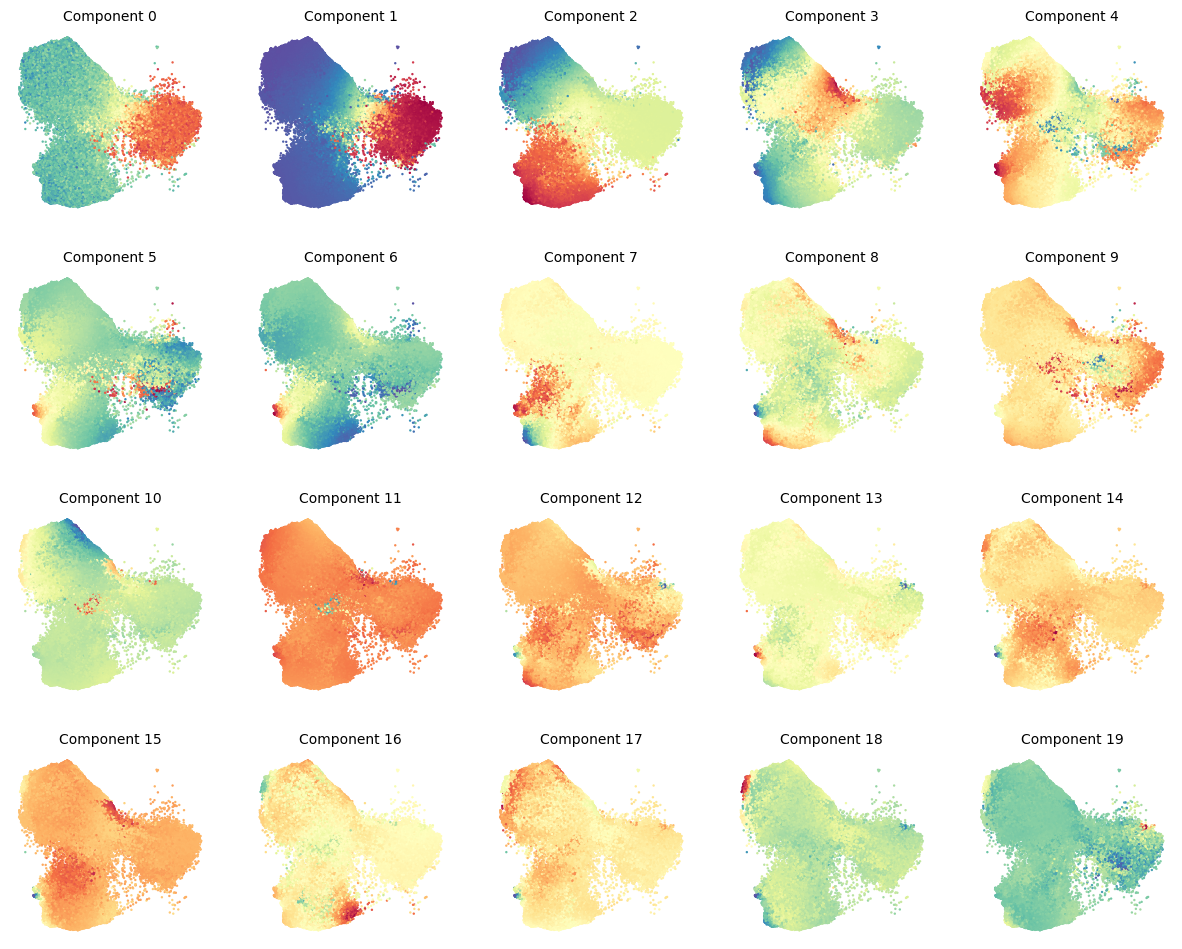

In [23]:
# Show Diffusion Plots ##

palantir.plot.plot_diffusion_components(ei_adata)
plt.show()

In [24]:
def get_centroid_cell(adata, groupby=None, group=None, obsm_key="X_scvi", return_coords=False):
    
    """
    Compute centroid of an AnnData subset in a chosen embedding space
    and return the closest real cell.

    Parameters
    ----------
    adata : AnnData
    groupby : str or None
        Column in adata.obs to subset by (e.g. 'subclass_annotations').
        If None, uses full object.
    group : str or None
        Category within groupby to subset (e.g. 'Deep Layer Neuron').
    obsm_key : str
        Embedding to use (e.g. 'X_scvi', 'X_pca', 'DM_EigenVectors_multiscaled').
    return_coords : bool
        If True, returns centroid coordinates instead of cell ID.

    Returns
    -------
    centroid_cell_id or centroid coordinates
    """

    # -------------------------
    # 1. Subset if needed
    # -------------------------
    if groupby is not None and group is not None:
        sub = adata[adata.obs[groupby] == group].copy()
    else:
        sub = adata

    # -------------------------
    # 2. Get embedding
    # -------------------------
    if obsm_key not in sub.obsm:
        raise KeyError(f"{obsm_key} not found in adata.obsm")

    X = sub.obsm[obsm_key]

    # -------------------------
    # 3. Compute centroid
    # -------------------------
    centroid = X.mean(axis=0)

    if return_coords:
        return centroid

    # -------------------------
    # 4. Find nearest cell
    # -------------------------
    distances = cdist(X, centroid.reshape(1, -1)).ravel()
    idx = np.argmin(distances)

    return sub.obs_names[idx]

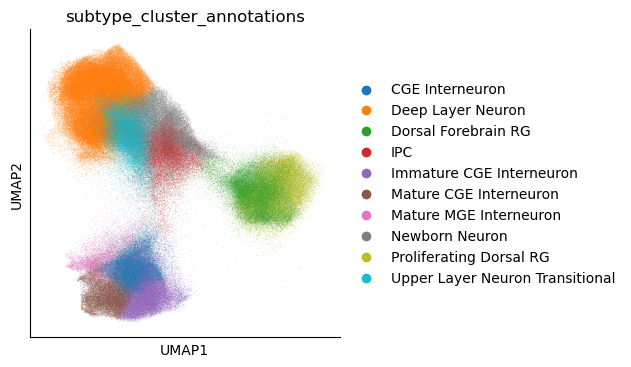

In [25]:
sc.pl.umap(ei_adata, color=['subtype_cluster_annotations'])

In [26]:
ei_adata.obs['subclass_annotations'].value_counts()

subclass_annotations
Dorsal Forebrain EN    222305
GABAergic              110161
Radial Glia             79291
Mixed Neurons           42695
Name: count, dtype: int64

In [27]:
## Get Terminal Day ##

excitatory_terminal_point = get_centroid_cell(ei_adata[ei_adata.obs['Day'] == 182.5], 
                            groupby="subclass_annotations", group="Dorsal Forebrain EN",
                            obsm_key="X_scVI")

inhibitory_terminal_point = get_centroid_cell(ei_adata[ei_adata.obs['Day'] == 182.5], 
                            groupby="subclass_annotations", group="GABAergic",
                            obsm_key="X_scVI")

starting_point = get_centroid_cell(ei_adata[ei_adata.obs['Day'] == 22.0], 
                            groupby="subclass_annotations", group="Radial Glia",
                            obsm_key="X_scVI")


print(excitatory_terminal_point)
print(inhibitory_terminal_point)
print(starting_point)

SRR32261343_CATGAGTAGCAAATGT
SRR32261361_CGTGTCTTCCTTCTGG
SRR23984452_ATACCGATCAGTGTGT


In [28]:
## Set Terminal States and Visualize ##

ei_adata.obs['terminal_states'] = ei_adata.obs['CellType']
ei_adata.obs['terminal_states'] = ei_adata.obs['terminal_states'].astype('str')
ei_adata.obs.loc[starting_point, 'terminal_states'] = 'starting_point'
ei_adata.obs.loc[inhibitory_terminal_point, 'terminal_states'] = 'inhibitory_terminal_point'
ei_adata.obs.loc[excitatory_terminal_point, 'terminal_states'] = 'excitatory_terminal_point'

In [29]:
ei_adata.obs['terminal_states'].value_counts()

terminal_states
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    198670
GABAergic GAD1+GAD2+CALB2+                     110160
Radial Glia SOX2+PAX6+FABP7+                    79290
Mixed Neurons FGF12+GRIN2B+CAMK2B+              42695
IPC EOMES+NEUROG2+PAX6+                         23634
inhibitory_terminal_point                           1
excitatory_terminal_point                           1
starting_point                                      1
Name: count, dtype: int64

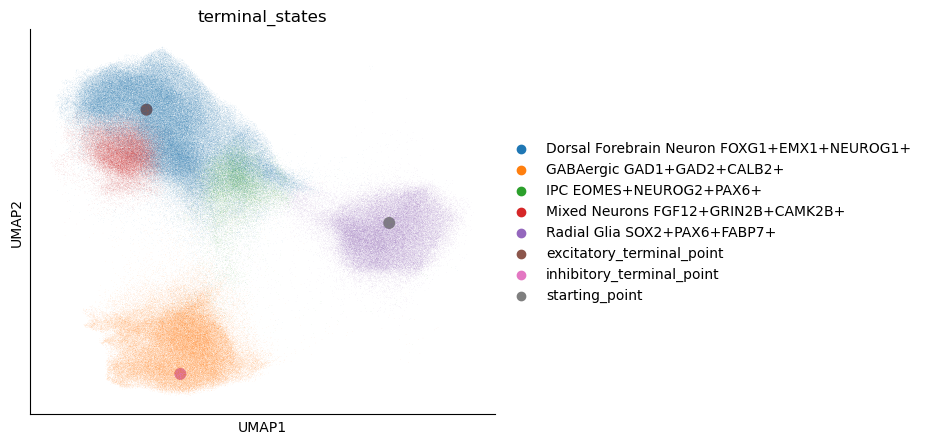

In [30]:
## Visualize Terminal States ##

ei_adata.obs['terminal_states_sizes'] = ei_adata.obs['terminal_states'].apply(lambda x: 300 if ((x == 'inhibitory_terminal_point') 
                                                                                             or (x == 'excitatory_terminal_point')
                                                                                             or (x == 'starting_point')) else 0.1)

# Create a figure and axes with the desired size
fig, ax = plt.subplots(figsize=(6, 5))

# Plot using Scanpy, but pass the axes explicitly
sc.pl.embedding(ei_adata, basis='umap', color='terminal_states',
                size=ei_adata.obs['terminal_states_sizes'],  ax=ax, show=False)

plt.show()

In [31]:
pr_res = palantir.core.run_palantir(ei_adata, starting_point, eigvec_key='DM_EigenVectors',
                                    num_waypoints=500, terminal_states=[inhibitory_terminal_point, excitatory_terminal_point])

Sampling and flocking waypoints...
Time for determining waypoints: 0.132952348391215 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/home/deepak/pixi_envs/scenic/.pixi/envs/default/l

Time for shortest paths: 3.9971303582191466 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9802
Correlation at iteration 2: 0.9998
Correlation at iteration 3: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


<Axes: xlabel='Day', ylabel='palantir_pseudotime'>

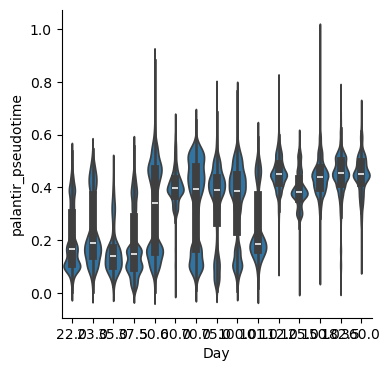

In [32]:
sns.violinplot(ei_adata.obs, x='Day', y='palantir_pseudotime', density_norm='width')

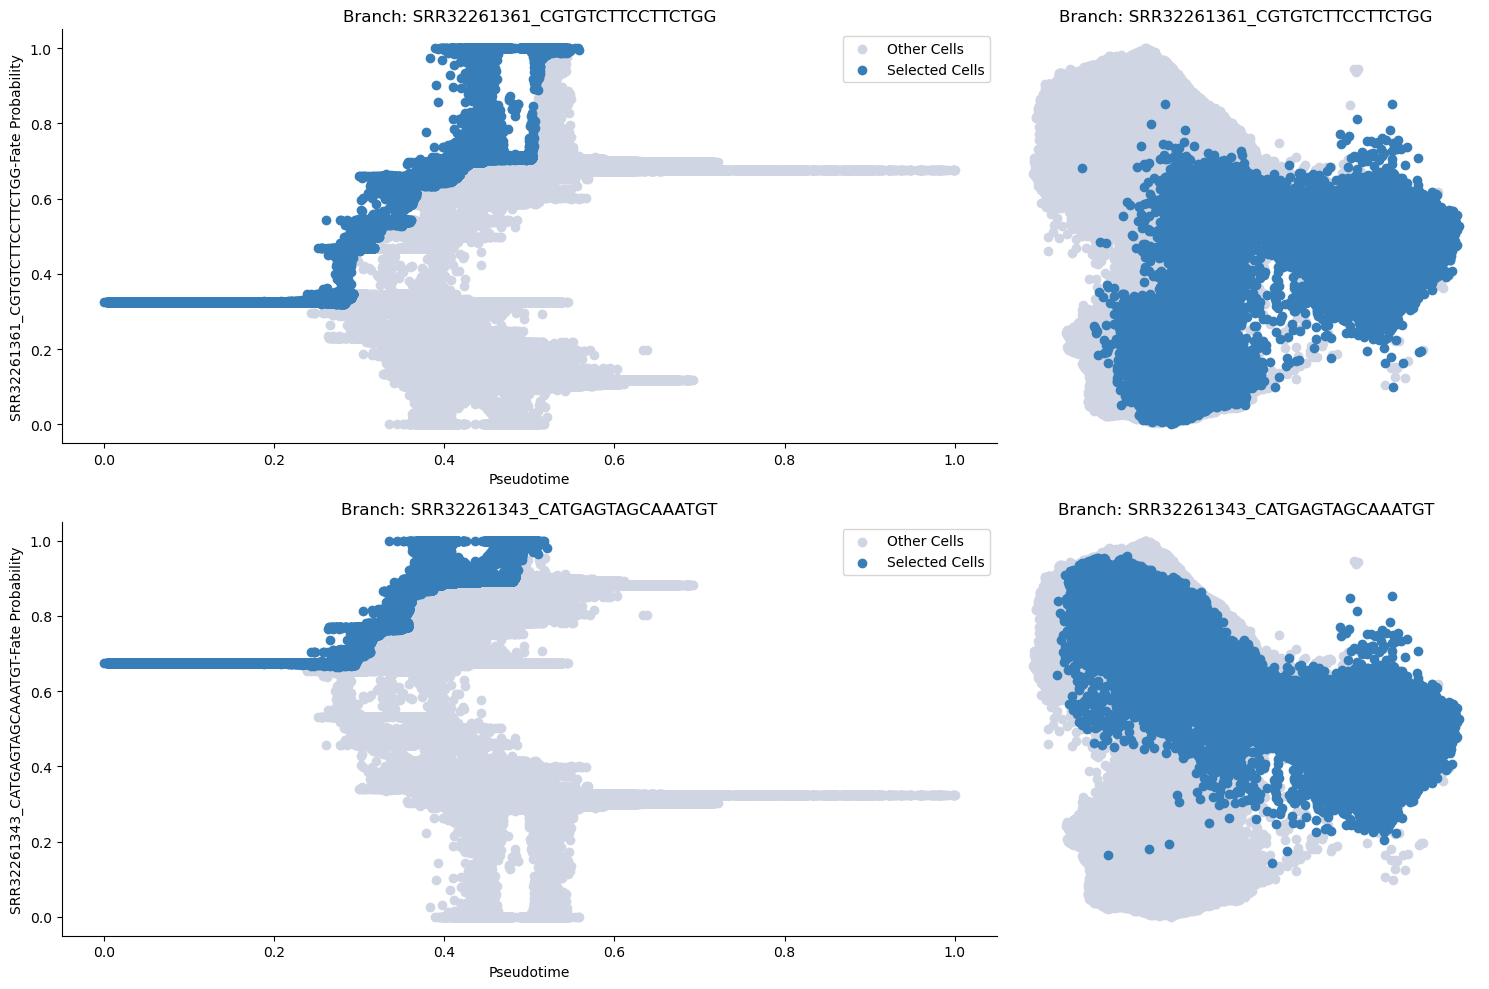

In [33]:
## Observe Branching Probabilities ##

masks = palantir.presults.select_branch_cells(ei_adata, q=.01, eps=.01)

palantir.plot.plot_branch_selection(ei_adata)

plt.show()

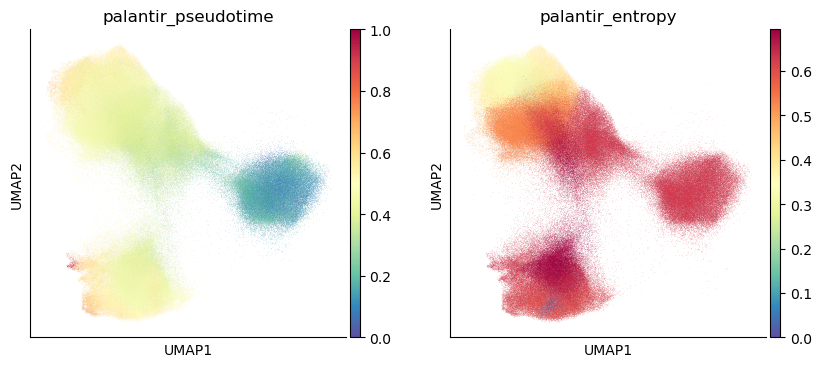

In [34]:
sc.pl.embedding(ei_adata, basis='umap', color=['palantir_pseudotime', 'palantir_entropy'], ncols=2)

In [35]:
## Examine Trajectories Branching ##

# Palantir branch probabilities
branch_probs = pr_res.branch_probs.copy()

# add cluster path pseudotime info
branch_probs = branch_probs.join(ei_adata.obs[['palantir_pseudotime', 'palantir_entropy']])

# rename columns
branch_probs.rename({'SRR32261343_CATGAGTAGCAAATGT':'Excitatory', 
                     'SRR32261361_CGTGTCTTCCTTCTGG':'Inhibitory'}, axis=1, inplace=True)

# get branching assigment (may disagree with Path)
branch_probs['assignment'] = branch_probs[branch_probs.columns[0:2]].idxmax(axis=1)

In [36]:
ei_adata.obs = ei_adata.obs.merge(branch_probs[['Excitatory', 'Inhibitory', 'assignment']], right_index=True, left_index=True, how='left')

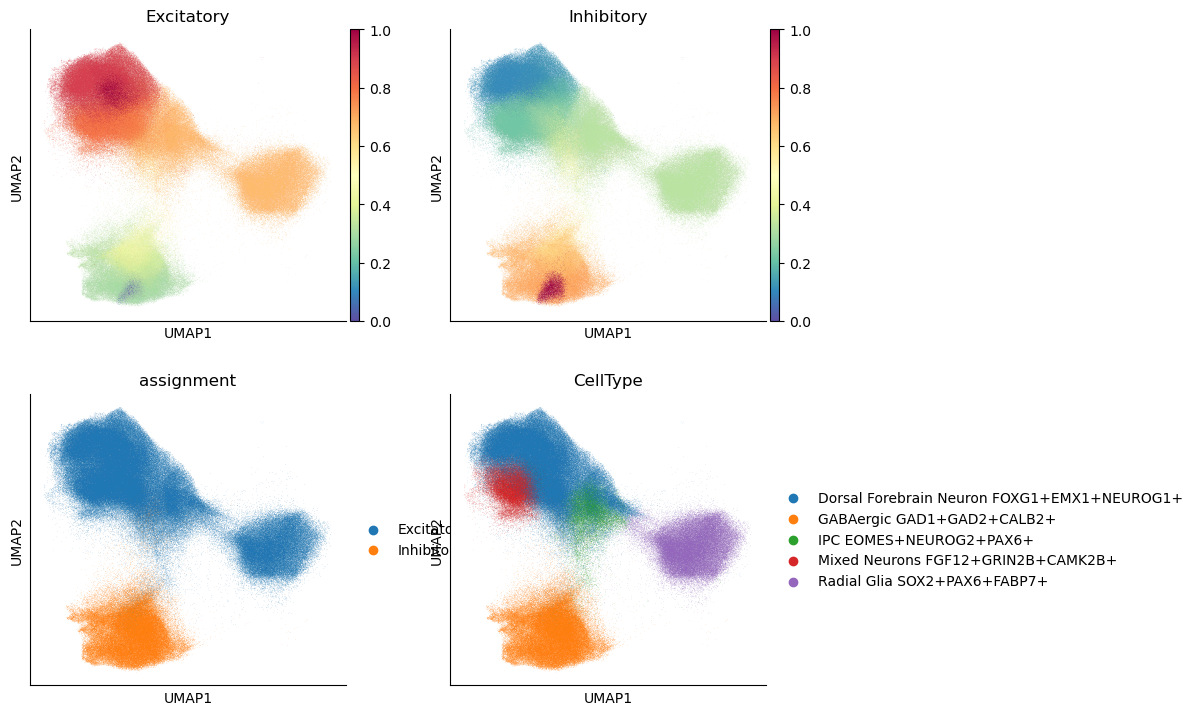

In [37]:
## UMAPs of Individual Trajectories ##

sc.pl.umap(ei_adata, color=['Excitatory', 'Inhibitory', 'assignment', 'CellType'], ncols=2)

In [38]:
branch_probs['CellType'] = ei_adata.obs['CellType']
branch_probs['Broad_Genotype'] = ei_adata.obs['Broad_Genotype']

In [39]:
gene_trends = palantir.presults.compute_gene_trends(ei_adata, expression_key="log1p_norm")

SRR32261343_CATGAGTAGCAAATGT
[2026-05-02 17:23:10,404] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (121,551) and rank = 1.0.
[2026-05-02 17:23:10,404] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-02 17:23:16,563] [INFO    ] Sigma interpreted as element-wise standard deviation.
SRR32261361_CGTGTCTTCCTTCTGG
[2026-05-02 17:23:41,525] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (121,094) and rank = 1.0.
[2026-05-02 17:23:41,525] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-02 17:23:44,096] [INFO    ] Sigma interpreted as element-wise standard deviation.


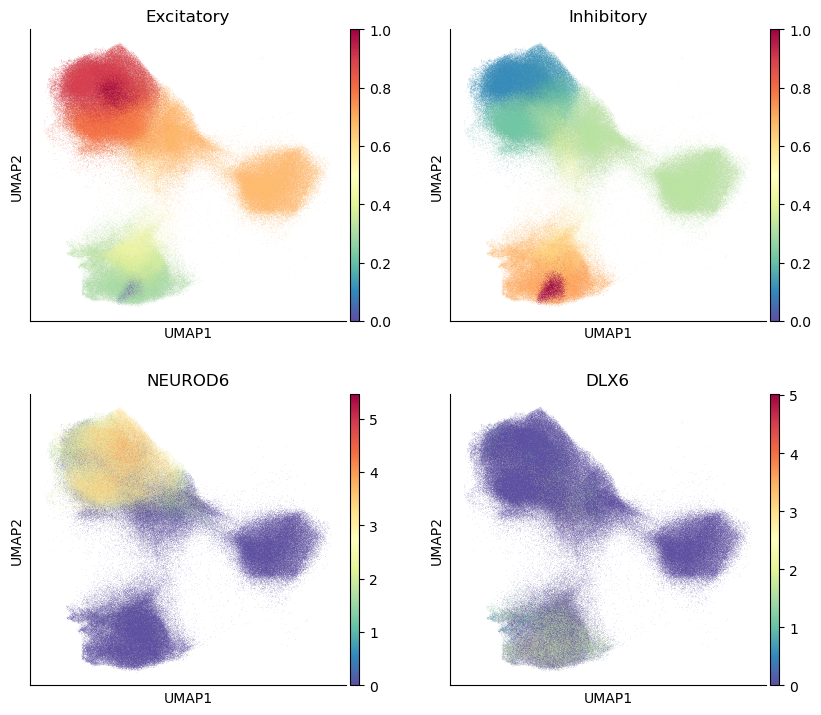

In [40]:
sc.pl.umap(ei_adata, color=['Excitatory', 'Inhibitory', 'NEUROD6', 'DLX6'], ncols=2)

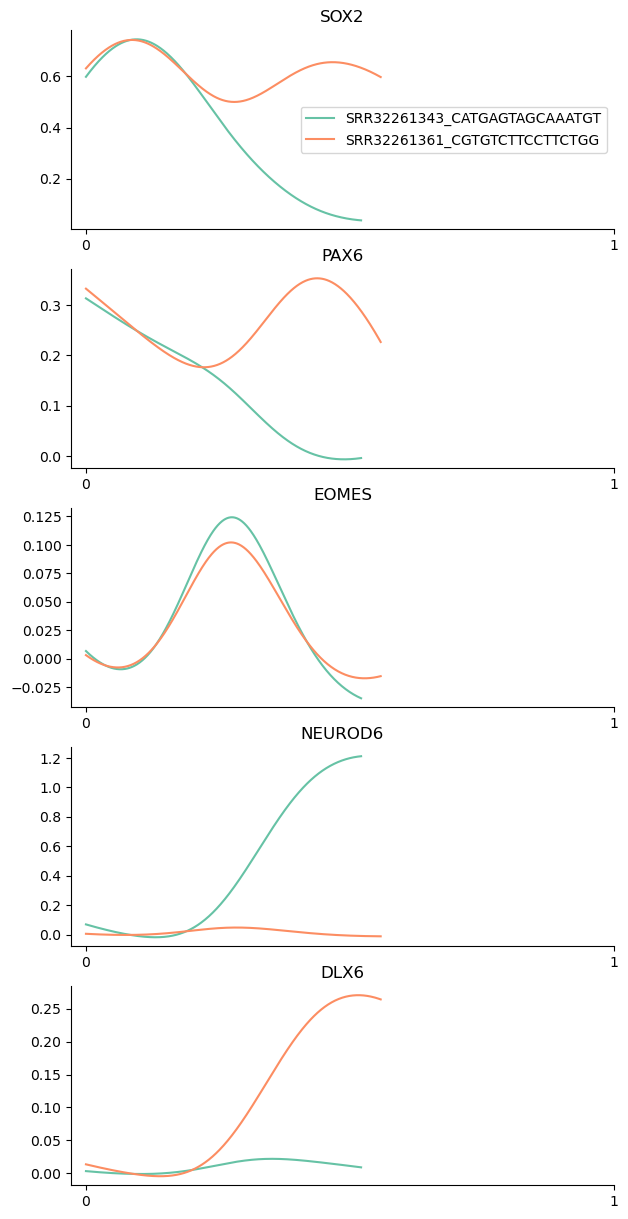

In [41]:
genes = ["SOX2", "PAX6", "EOMES", "NEUROD6", "DLX6"]
palantir.plot.plot_gene_trends(ei_adata, genes, branch_names=['SRR32261343_CATGAGTAGCAAATGT', 'SRR32261361_CGTGTCTTCCTTCTGG'])
plt.show()

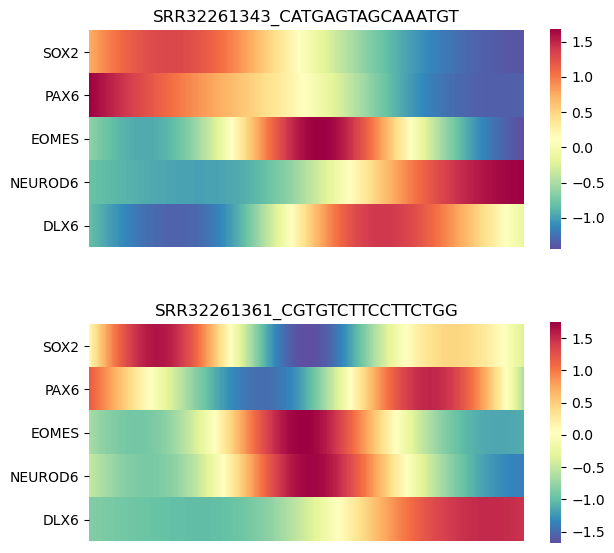

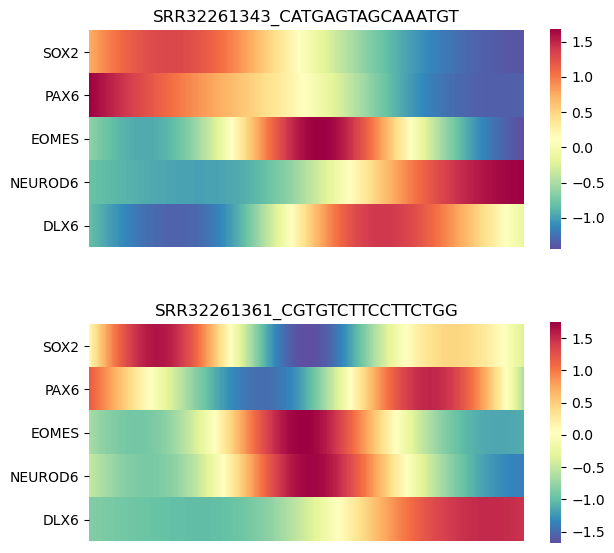

In [42]:
palantir.plot.plot_gene_trend_heatmaps(ei_adata, genes, gene_trend_key="gene_trends",
                                       branch_names=['SRR32261343_CATGAGTAGCAAATGT', 'SRR32261361_CGTGTCTTCCTTCTGG'])

In [45]:
sc.pp.neighbors(ei_adata, use_rep='X_scVI', n_neighbors=15)
sc.tl.leiden(ei_adata, resolution=3)

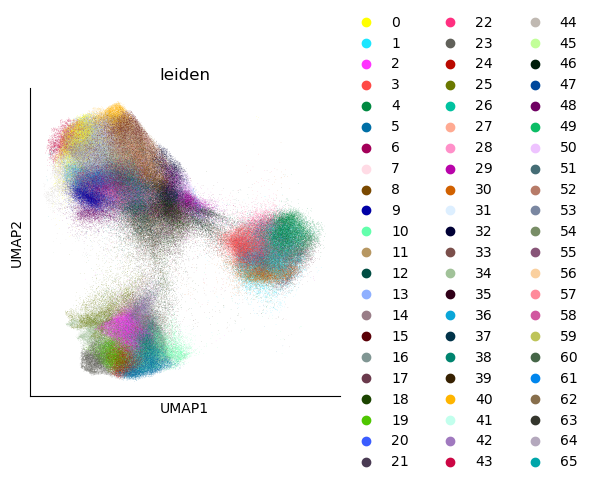

In [46]:
sc.pl.umap(ei_adata, color='leiden')

In [47]:
## SCVI PB ##

scvi_df = pd.DataFrame(data=ei_adata.obsm['X_scVI'],
                     index=ei_adata.obs_names,
                     columns=[f"LATENT_DIM_{str(i)}" for i in range(ei_adata.obsm['X_scVI'].shape[1])])

ei_adata.obs['Clusters'] = ei_adata.obs['leiden']

ei_adata.obs['Cluster'] = pd.Series(np.where(ei_adata.obs['CellType'].str.contains('GABAergic|Dorsal', na=False), ei_adata.obs['CellType'], ei_adata.obs['leiden']), 
                                    index=ei_adata.obs.index)

scvi_df['Cluster'] = ei_adata.obs['Cluster']

scvi_pbd = scvi_df.groupby('Cluster').mean()

cluster_to_path = dict(zip(scvi_pbd.T.corr().index, 
                       scvi_pbd.T.corr()[["Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+", 
                                           "GABAergic GAD1+GAD2+CALB2+"]].idxmax(axis=1)))

ei_adata.obs['Path'] = ei_adata.obs['Cluster'].map(cluster_to_path)

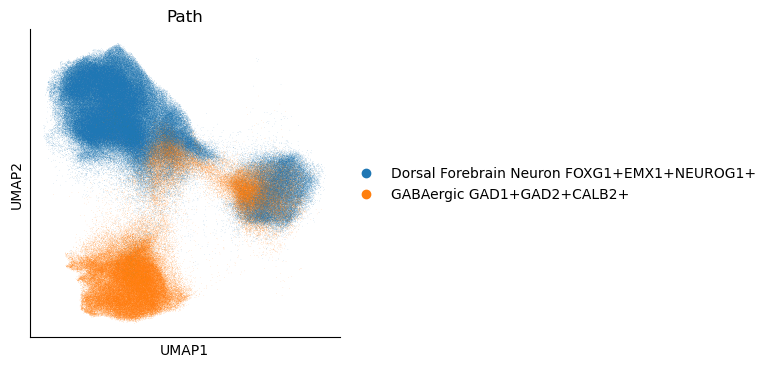

In [48]:
sc.pl.umap(ei_adata, color='Path')

In [49]:
## Write Files To Disk ##

# ei branch probs

branch_probs['Path'] = ei_adata.obs['Path']

branch_probs.to_csv('/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/ei_branch_probs.csv')

# write dreamlet chose #
ei_adata.X = ei_adata.layers['raw_counts']
del ei_adata.obsm
del ei_adata.obsp
del ei_adata.layers
ei_adata.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/ei_adata_dreamlet.h5ad')

# pickle gene trends #
out_path = "/mnt/sdb/scz_meta_analysis_processed/trajectory_analyses/ei_gene_trends.pkl"

with open(out_path, "wb") as f:
    pickle.dump(gene_trends, f, protocol=pickle.HIGHEST_PROTOCOL)